/var/folders/7v/pr834dkj565_7hcxjrjyjqn40000gn/T/ipykernel_12792/3990737608.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coldest.values, y=coldest.index, ax=axes[0], palette="Blues_d")
/var/folders/7v/pr834dkj565_7hcxjrjyjqn40000gn/T/ipykernel_12792/3990737608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hottest.values, y=hottest.index, ax=axes[1], palette="Reds_r")


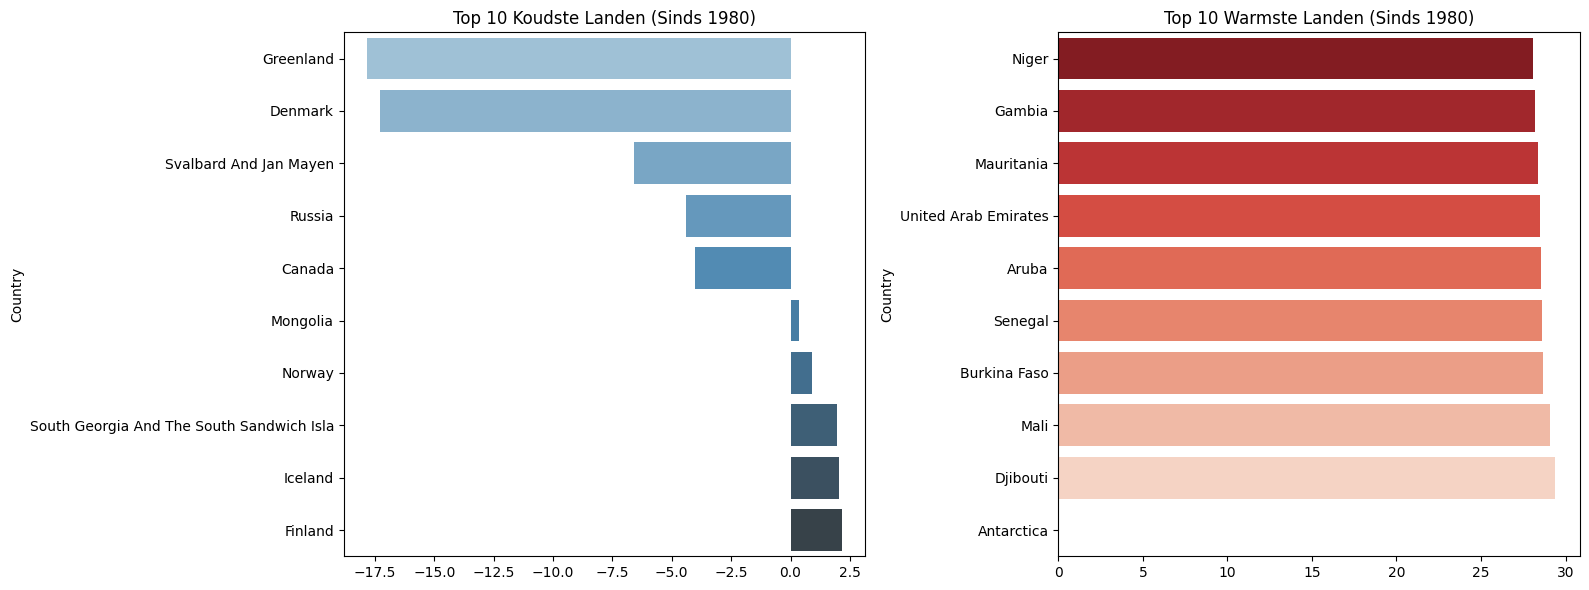

In [3]:
# 4. Analyse: top 10 warmste en koudste landen
country_means = df_clean.groupby('Country')[col_name].mean().sort_values()

coldest = country_means.head(10)
hottest = country_means.tail(10)

# 5. Visualisatie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=coldest.values, y=coldest.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 Koudste Landen (Sinds 1980)')

sns.barplot(x=hottest.values, y=hottest.index, ax=axes[1], palette="Reds_r")
axes[1].set_title('Top 10 Warmste Landen (Sinds 1980)')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
import seaborn as sns

# Verbinding maken
engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

# 1. Haal de SCHONE stad-data op
df_city = pd.read_sql("SELECT * FROM cleaned_global_temp_major_city", engine)
df_city['dt'] = pd.to_datetime(df_city['dt'])

# 2. Bereken de 'Range' (verschil tussen max en min) per stad
city_extremes = df_city.groupby('city')['average_temp'].agg(['max', 'min']).reset_index()
city_extremes['diff'] = city_extremes['max'] - city_extremes['min']

# Sorteer op het grootste verschil
city_extremes = city_extremes.sort_values(by='diff', ascending=False)

# Toon de top 5 steden met de grootste seizoenschommelingen
print("Steden met de grootste temperatuurverschillen:")
display(city_extremes.head(5))

# Pak de namen van de top 3 voor de grafiek
top_3_cities = city_extremes.head(3)['City'].tolist()

Steden met de grootste temperatuurverschillen:


,city,max,min,diff
34,Harbin,25.357,-23.495,48.852
19,Changchun,25.671,-20.871,46.542
65,Moscow,24.580,-18.870,43.450
85,Shenyang,26.010,-14.832,40.842
79,Saint Petersburg,21.921,-18.589,40.510


KeyError: 'City'

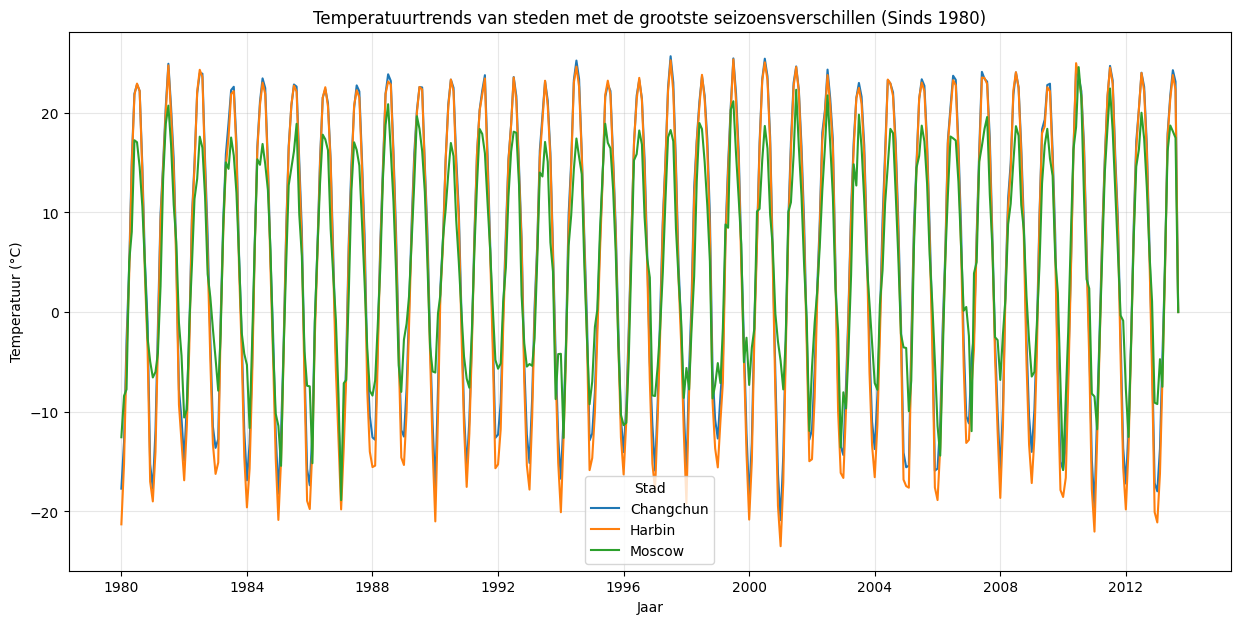

In [5]:
# Pak de namen van de top 3 voor de grafiek (nu met kleine letter 'city')
top_3_cities = city_extremes.head(3)['city'].tolist()

# Filter de data voor de top 3 steden
df_plot = df_city[df_city['city'].isin(top_3_cities)]

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_plot, x='dt', y='average_temp', hue='city')

plt.title('Temperatuurtrends van steden met de grootste seizoensverschillen (Sinds 1980)')
plt.xlabel('Jaar')
plt.ylabel('Temperatuur (°C)')
plt.legend(title='Stad')
plt.grid(True, alpha=0.3)

plt.show()